ACROSS-PARTICIPANT RSA

ISPC: correlates each participant's voxel pattern for each event with the group mean pattern for that event (excluding themselves)
separately for moral and non-moral sentences
average across left and right hemisphere
paired t test


In [2]:
import os
import numpy as np
from nilearn import image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, zscore, ttest_rel, pearsonr, ttest_ind
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
import seaborn as sns
from scipy.stats import sem
from scipy.signal import detrend


In [3]:
foundationScores_dir = "/Users/silvycollin/Documents/GitHub/wholeBrain_narratives_MAC_MFT/text/foundationScores/"

whichFoundationScore = "MAC_a_moral_nonmoral"

In [4]:

# save
save_dir = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/RSA/"
)

groupSplit_dir = os.path.expanduser(
        "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/"
    )

In [5]:
# ------------------------
# Load 
# ------------------------

whichROI = "antSTG_MTG_refined_mask" # hippocampus,TPJ_refined_mask,posSTG_MTG_refined_mask,antSTG_MTG_refined_mask,tempPole_HOonly

whichStory1 = "shapessocial"  
whichStory2 = "shapesphysical" 

base_dir = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_0/"
)

foundationScores_file1 = f"{foundationScores_dir}{whichStory1}_MFT_MAC.xlsx"
foundationScores_social = pd.read_excel(foundationScores_file1)

foundationScores_file2 = f"{foundationScores_dir}{whichStory2}_MFT_MAC.xlsx"
foundationScores_physical = pd.read_excel(foundationScores_file2)

print(whichROI)

data_dir1 = f"{base_dir}{whichStory1}/"
data_dir2 = f"{base_dir}{whichStory2}/"

left_social = np.load(data_dir1 + f"{whichStory1}_0_{whichROI}_L_3D_clean.npy")
right_social = np.load(data_dir1 + f"{whichStory1}_0_{whichROI}_R_3D_clean.npy")

left_physical = np.load(data_dir2 + f"{whichStory2}_0_{whichROI}_L_3D_clean.npy")
right_physical = np.load(data_dir2 + f"{whichStory2}_0_{whichROI}_R_3D_clean.npy")


antSTG_MTG_refined_mask


In [6]:
# ------------------------
# load foundation scores 
# ------------------------
# start and end column is start and end of the sentences in seconds, TR was 1.5 sec

foundationScoresSelect_social = foundationScores_social[[whichFoundationScore,"start","end"]]
foundationScoresSelect_social = foundationScoresSelect_social.copy()

# go from seconds to TRs for start and end column
foundationScoresSelect_social["startTR"] = foundationScoresSelect_social["start"] / 1.5
foundationScoresSelect_social["endTR"] = foundationScoresSelect_social["end"] / 1.5

# round to full TRs/volumes
foundationScoresSelect_social["startTR"] = foundationScoresSelect_social["startTR"].round(0).astype(int)
foundationScoresSelect_social["endTR"] = foundationScoresSelect_social["endTR"].round(0).astype(int)

# shift by 3 TRs for the HRF
foundationScoresSelect_social['startTR'] = foundationScoresSelect_social['startTR'] + 3
foundationScoresSelect_social['endTR'] = foundationScoresSelect_social['endTR'] + 3



foundationScoresSelect_physical = foundationScores_physical[[whichFoundationScore,"start","end"]]
foundationScoresSelect_physical = foundationScoresSelect_physical.copy()

# go from seconds to TRs for start and end column
foundationScoresSelect_physical["startTR"] = foundationScoresSelect_physical["start"] / 1.5
foundationScoresSelect_physical["endTR"] = foundationScoresSelect_physical["end"] / 1.5

# round to full TRs/volumes
foundationScoresSelect_physical["startTR"] = foundationScoresSelect_physical["startTR"].round(0).astype(int)
foundationScoresSelect_physical["endTR"] = foundationScoresSelect_physical["endTR"].round(0).astype(int)

# shift by 3 TRs for the HRF
foundationScoresSelect_physical['startTR'] = foundationScoresSelect_physical['startTR'] + 3
foundationScoresSelect_physical['endTR'] = foundationScoresSelect_physical['endTR'] + 3


In [7]:
# split into the moral vs non moral sentences
foundationScoresSelect_nonzero_social = foundationScoresSelect_social[foundationScoresSelect_social[whichFoundationScore] != 0]

foundationScoresSelect_zero_social = foundationScoresSelect_social[foundationScoresSelect_social[whichFoundationScore] == 0]

foundationScoresSelect_nonzero_physical = foundationScoresSelect_physical[foundationScoresSelect_physical[whichFoundationScore] != 0]

foundationScoresSelect_zero_physical = foundationScoresSelect_physical[foundationScoresSelect_physical[whichFoundationScore] == 0]


Running ISPC for LEFT hemisphere...
Running ISPC for RIGHT hemisphere...
Running ISPC for LEFT hemisphere...
Running ISPC for RIGHT hemisphere...

Participant-level ISPC results
SOCIAL   : t = -4.18, p = 0.0001
PHYSICAL : t = 3.37, p = 0.0013
MORAL : t = 4.35, p = 0.0001
NONMORAL : t = 7.67, p = 0.0000


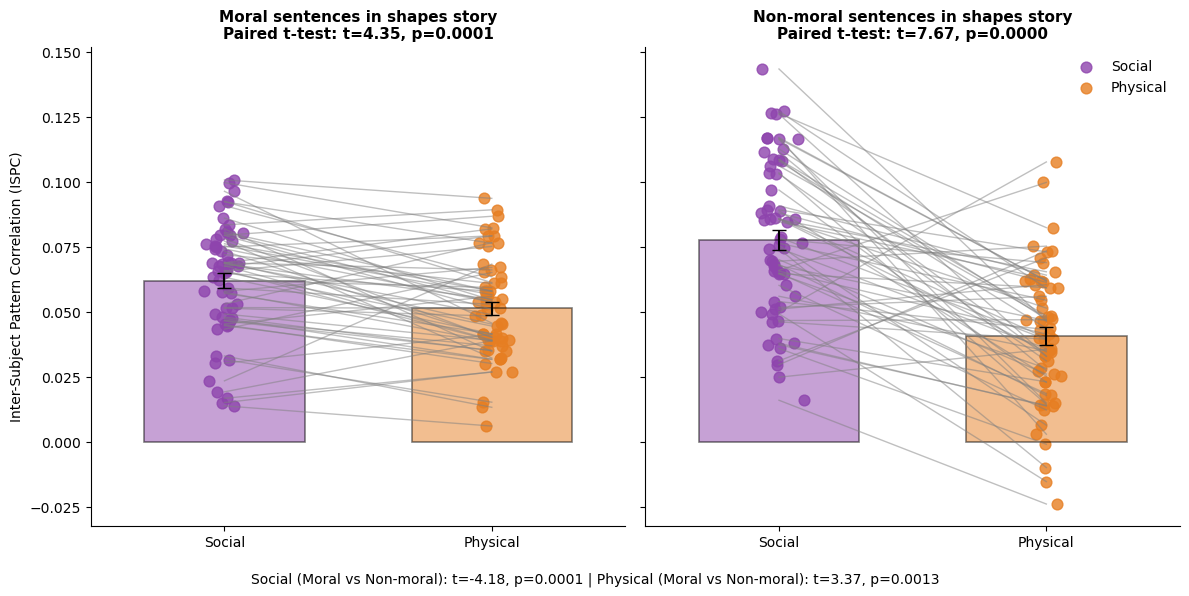

In [8]:

# ================================================================
# Function: Inter-Subject Pattern Correlation (ISPC)
# ================================================================
def run_inter_subject_pattern_correlation(data_array, events):
    """
    Compute inter-subject pattern correlation (ISPC) for each event
    and return the average ISPC per participant.
    
    data_array : np.ndarray
        Shape (voxels x TRs x participants)
    events : pd.DataFrame
        Columns ['startTR', 'endTR']
    
    Returns
    -------
    ispc_per_participant : np.ndarray
        Mean ISPC per participant across all events.
    """
    # Clean and prepare events
    events = events.dropna(subset=['startTR', 'endTR']).sort_values('startTR').reset_index(drop=True)
    events['startTR'] = events['startTR'].astype(int)
    events['endTR'] = events['endTR'].astype(int)
    n_events = len(events)
    n_vox, n_tr, n_part = data_array.shape

    # Z-score each participant voxelwise over time
    data_z = np.zeros_like(data_array)
    for p in range(n_part):
        z = zscore(data_array[:, :, p], axis=1, ddof=1)
        z[np.isnan(z)] = 0
        data_z[:, :, p] = z

    # Compute mean spatial pattern per event per participant
    event_patterns = np.zeros((n_vox, n_events, n_part))
    for i, ev in events.iterrows():
        start_tr = int(ev['startTR'])
        end_tr = int(ev['endTR'])
        event_patterns[:, i, :] = np.mean(data_z[:, start_tr:end_tr + 1, :], axis=1)

    # Compute ISPC (inter-subject pattern correlation)
    ispc_per_participant = np.zeros(n_part)
    for p in range(n_part):
        others = np.delete(np.arange(n_part), p)
        corrs = []
        for i in range(n_events):
            this_pattern = event_patterns[:, i, p]
            others_mean = np.mean(event_patterns[:, i, others], axis=1)
            
            # nan_indices = np.argwhere(np.isnan(others_mean))
            # print('shape ', others_mean.shape)
            # print(nan_indices)
            
            r, _ = pearsonr(this_pattern, others_mean)
            corrs.append(r)
        ispc_per_participant[p] = np.mean(corrs)
    
    return ispc_per_participant


# ================================================================
# Run ISPC for both hemispheres (moral and non-moral) and for social shapes and physical shapes
# ================================================================
print("Running ISPC for LEFT hemisphere...")
ispc_moral_part_L_social = run_inter_subject_pattern_correlation(left_social, foundationScoresSelect_nonzero_social)
ispc_nonmoral_part_L_social = run_inter_subject_pattern_correlation(left_social, foundationScoresSelect_zero_social)

print("Running ISPC for RIGHT hemisphere...")
ispc_moral_part_R_social = run_inter_subject_pattern_correlation(right_social, foundationScoresSelect_nonzero_social)
ispc_nonmoral_part_R_social = run_inter_subject_pattern_correlation(right_social, foundationScoresSelect_zero_social)

ispc_moral_part_avg_social = (ispc_moral_part_L_social + ispc_moral_part_R_social) / 2
ispc_nonmoral_part_avg_social = (ispc_nonmoral_part_L_social + ispc_nonmoral_part_R_social) / 2

# ================================================================
print("Running ISPC for LEFT hemisphere...")
ispc_moral_part_L_physical = run_inter_subject_pattern_correlation(left_physical, foundationScoresSelect_nonzero_physical)
ispc_nonmoral_part_L_physical = run_inter_subject_pattern_correlation(left_physical, foundationScoresSelect_zero_physical)

print("Running ISPC for RIGHT hemisphere...")
ispc_moral_part_R_physical = run_inter_subject_pattern_correlation(right_physical, foundationScoresSelect_nonzero_physical)
ispc_nonmoral_part_R_physical = run_inter_subject_pattern_correlation(right_physical, foundationScoresSelect_zero_physical)

ispc_moral_part_avg_physical = (ispc_moral_part_L_physical + ispc_moral_part_R_physical) / 2
ispc_nonmoral_part_avg_physical = (ispc_nonmoral_part_L_physical + ispc_nonmoral_part_R_physical) / 2

# ================================================================
# Paired t-tests
# ================================================================
tval_social, pval_social = ttest_rel(
    ispc_moral_part_avg_social,
    ispc_nonmoral_part_avg_social
)

tval_physical, pval_physical = ttest_rel(
    ispc_moral_part_avg_physical,
    ispc_nonmoral_part_avg_physical
)

tval_moral, pval_moral = ttest_rel(
    ispc_moral_part_avg_social,
    ispc_moral_part_avg_physical
)

tval_nonmoral, pval_nonmoral = ttest_rel(
    ispc_nonmoral_part_avg_social,
    ispc_nonmoral_part_avg_physical
)

print("\n===============================")
print("Participant-level ISPC results")
print("===============================")
print(f"SOCIAL   : t = {tval_social:.2f}, p = {pval_social:.4f}")
print(f"PHYSICAL : t = {tval_physical:.2f}, p = {pval_physical:.4f}")
print(f"MORAL : t = {tval_moral:.2f}, p = {pval_moral:.4f}")
print(f"NONMORAL : t = {tval_nonmoral:.2f}, p = {pval_nonmoral:.4f}")

# ================================================================
# Visualization: split by MORAL vs NON-MORAL
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

colors = ['#8E44AD', '#E67E22']  # Social, Physical
x_pos = [0, 1]

panels = [
    ("Moral sentences in shapes story",
     ispc_moral_part_avg_social,
     ispc_moral_part_avg_physical,
     tval_moral,
     pval_moral),
    ("Non-moral sentences in shapes story",
     ispc_nonmoral_part_avg_social,
     ispc_nonmoral_part_avg_physical,
     tval_nonmoral,  
     pval_nonmoral)
]

for ax, (title, cond1, cond2, tval, pval) in zip(axes, panels):

    n_subs = len(cond1)

    # Connect lines per participant 
    for i in range(n_subs):
        ax.plot(
            x_pos,
            [cond1[i], cond2[i]],
            color='gray', alpha=0.5, linewidth=1
        )

    # Jittered dots
    ax.scatter(
        np.zeros(n_subs) + np.random.normal(0, 0.03, n_subs),
        cond1,
        color=colors[0], s=60, alpha=0.8, label='Social'
    )

    ax.scatter(
        np.ones(n_subs) + np.random.normal(0, 0.03, n_subs),
        cond2,
        color=colors[1], s=60, alpha=0.8, label='Physical'
    )

    # Mean + SEM
    mean_vals = [np.mean(cond1), np.mean(cond2)]
    sem_vals = [
        np.std(cond1, ddof=1) / np.sqrt(n_subs),
        np.std(cond2, ddof=1) / np.sqrt(n_subs)
    ]

    ax.bar(
        x_pos, mean_vals, yerr=sem_vals,
        color=colors, alpha=0.5, width=0.6,
        capsize=5, edgecolor='black', linewidth=1.2
    )

    # Axis & labels
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Social', 'Physical'])
    ax.set_title(
        f"{title}\nPaired t-test: t={tval:.2f}, p={pval:.4f}",
        fontsize=11, weight='bold'
    )
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(-0.5, 1.5)

axes[0].set_ylabel('Inter-Subject Pattern Correlation (ISPC)')
axes[1].legend(frameon=False)


fig.text(
    0.5, 0.02,
    f"Social (Moral vs Non-moral): t={tval_social:.2f}, p={pval_social:.4f} | "
    f"Physical (Moral vs Non-moral): t={tval_physical:.2f}, p={pval_physical:.4f}",
    ha='center', fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(
    str(save_dir) +
    f"ISPC_MoralNonmoral_SocialPhysical_{whichROI}_bothShapesStories_perSentence.png",
    dpi=300
)
plt.show()



# group split for SHAPES

In [10]:


TaskOrder = pd.read_csv(groupSplit_dir+'NarrativesParticipants.csv')
TaskOrder = TaskOrder[['BIDS ID','Notes','Manipulation']]
TaskOrder = TaskOrder.dropna(how='all')
# remove duplicate rows, only 1 row per participant
TaskOrder = TaskOrder[TaskOrder['Manipulation'] == 'social']


In [11]:

def classify_order(row):
    items = [x.strip() for x in row["Notes"].split(",")]
    # Find positions, return None if not present
    try:
        pos_social = items.index("social")
        pos_physical = items.index("physical")
    except ValueError:
        return None  # one of them missing

    if pos_social < pos_physical:
        return "social_first"
    elif pos_physical < pos_social:
        return "physical_first"
    else:
        return None

TaskOrder["order"] = TaskOrder.apply(classify_order, axis=1)

social_first_ids = TaskOrder.loc[TaskOrder["order"] == "social_first", "BIDS ID"].tolist()
physical_first_ids = TaskOrder.loc[TaskOrder["order"] == "physical_first", "BIDS ID"].tolist()

print("social_first_ids", social_first_ids)
print("physical_first_ids", physical_first_ids)


social_first_ids ['sub-049', 'sub-058', 'sub-181', 'sub-186', 'sub-190', 'sub-200', 'sub-206', 'sub-207', 'sub-208', 'sub-209', 'sub-210', 'sub-211', 'sub-212', 'sub-221', 'sub-222', 'sub-223', 'sub-224', 'sub-225', 'sub-226', 'sub-227', 'sub-228', 'sub-229', 'sub-230', 'sub-231', 'sub-232', 'sub-233', 'sub-234', 'sub-235', 'sub-236', 'sub-237']
physical_first_ids ['sub-095', 'sub-115', 'sub-127', 'sub-191', 'sub-201', 'sub-213', 'sub-214', 'sub-215', 'sub-216', 'sub-217', 'sub-218', 'sub-219', 'sub-220', 'sub-238', 'sub-239', 'sub-240', 'sub-241', 'sub-242', 'sub-243', 'sub-244', 'sub-245', 'sub-246', 'sub-247', 'sub-248', 'sub-249', 'sub-250', 'sub-251', 'sub-252', 'sub-253']


In [12]:
# Remove sub-238 from the physical-first list
physical_first_ids = [x for x in physical_first_ids if x != "sub-238"]

# Convert BIDS IDs ("sub-049") → integers (49)
social_ids_int = sorted([int(x.split("-")[1]) for x in social_first_ids])
physical_ids_int = sorted([int(x.split("-")[1]) for x in physical_first_ids])

# Build full sorted ID list (should now be 58 IDs)
all_ids_sorted = sorted(social_ids_int + physical_ids_int)

# Map IDs to array indices (0–57)
id_to_index = {sub_id: idx for idx, sub_id in enumerate(all_ids_sorted)}

# Create index lists for each group
social_idx = [id_to_index[i] for i in social_ids_int]
physical_idx = [id_to_index[i] for i in physical_ids_int]

# Split arrays
moral_socialshapes_socialfirst = ispc_moral_part_avg_social[social_idx]
moral_socialshapes_physicalfirst = ispc_moral_part_avg_social[physical_idx]

nonmoral_socialshapes_socialfirst = ispc_nonmoral_part_avg_social[social_idx]
nonmoral_socialshapes_physicalfirst = ispc_nonmoral_part_avg_social[physical_idx]


moral_physicalshapes_socialfirst = ispc_moral_part_avg_physical[social_idx]
moral_physicalshapes_physicalfirst = ispc_moral_part_avg_physical[physical_idx]

nonmoral_physicalshapes_socialfirst = ispc_nonmoral_part_avg_physical[social_idx]
nonmoral_physicalshapes_physicalfirst = ispc_nonmoral_part_avg_physical[physical_idx]



In [13]:
from scipy.stats import ttest_ind, ttest_rel

# ================================================================
# ORDER effects (between-subjects)
# ================================================================
stats_order = {}

stats_order['Social_Moral'] = ttest_ind(
    moral_socialshapes_socialfirst,
    moral_socialshapes_physicalfirst
)

stats_order['Social_Nonmoral'] = ttest_ind(
    nonmoral_socialshapes_socialfirst,
    nonmoral_socialshapes_physicalfirst
)

stats_order['Physical_Moral'] = ttest_ind(
    moral_physicalshapes_socialfirst,
    moral_physicalshapes_physicalfirst
)

stats_order['Physical_Nonmoral'] = ttest_ind(
    nonmoral_physicalshapes_socialfirst,
    nonmoral_physicalshapes_physicalfirst
)

# ================================================================
# MORALITY effects (within-subjects)
# ================================================================
stats_morality = {}

stats_morality['Social_SF'] = ttest_rel(
    moral_socialshapes_socialfirst,
    nonmoral_socialshapes_socialfirst
)

stats_morality['Social_PF'] = ttest_rel(
    moral_socialshapes_physicalfirst,
    nonmoral_socialshapes_physicalfirst
)

stats_morality['Physical_SF'] = ttest_rel(
    moral_physicalshapes_socialfirst,
    nonmoral_physicalshapes_socialfirst
)

stats_morality['Physical_PF'] = ttest_rel(
    moral_physicalshapes_physicalfirst,
    nonmoral_physicalshapes_physicalfirst
)


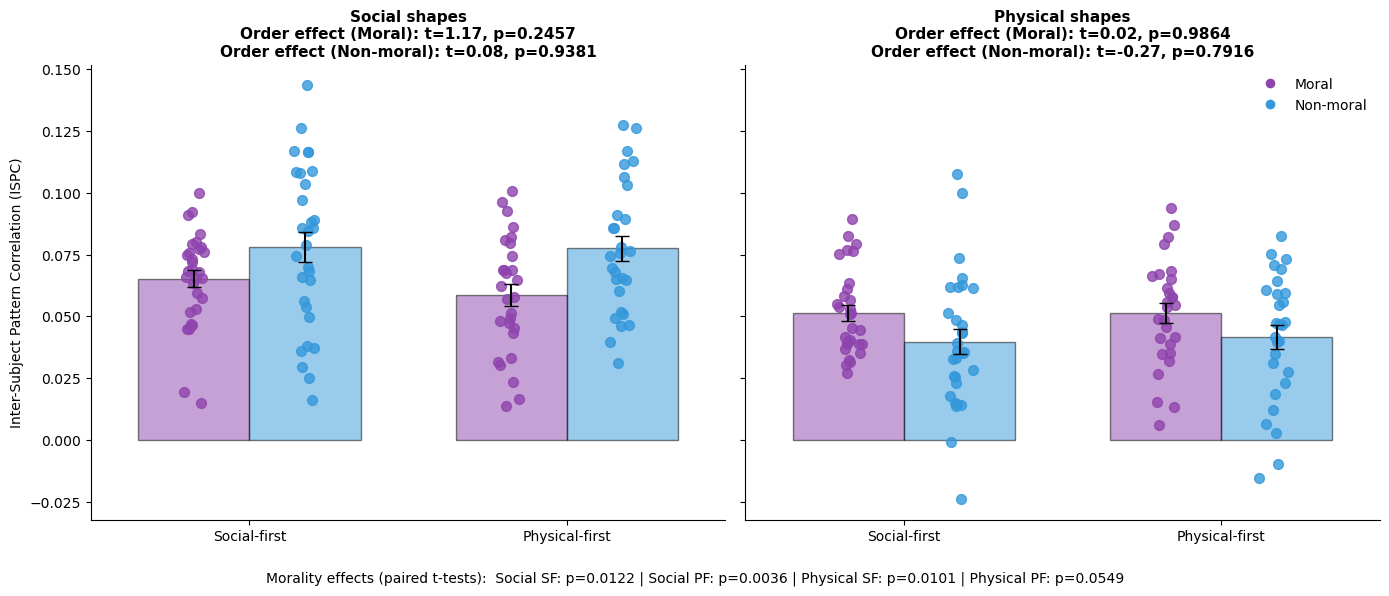

In [14]:
# ================================================================
# Visualization: 8-bar mixed design
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

colors = {
    'Moral': '#8E44AD',
    'Non-moral': '#3498DB'
}

x_pos = np.array([0, 1])  # Social-first, Physical-first
bar_width = 0.35
offsets = [-bar_width/2, bar_width/2]

panels = [
    ("Social shapes",
     moral_socialshapes_socialfirst,
     moral_socialshapes_physicalfirst,
     nonmoral_socialshapes_socialfirst,
     nonmoral_socialshapes_physicalfirst,
     stats_order['Social_Moral'],
     stats_order['Social_Nonmoral']),
    
    ("Physical shapes",
     moral_physicalshapes_socialfirst,
     moral_physicalshapes_physicalfirst,
     nonmoral_physicalshapes_socialfirst,
     nonmoral_physicalshapes_physicalfirst,
     stats_order['Physical_Moral'],
     stats_order['Physical_Nonmoral'])
]

for ax, (title,
         moral_sf, moral_pf,
         nonmoral_sf, nonmoral_pf,
         stat_moral, stat_nonmoral) in zip(axes, panels):

    data = [
        (moral_sf, 'Moral'),
        (nonmoral_sf, 'Non-moral'),
        (moral_pf, 'Moral'),
        (nonmoral_pf, 'Non-moral')
    ]

    # ---- Bars + dots
    for i, ((vals, label), offset) in enumerate(zip(data, offsets * 2)):

        x = x_pos[i // 2] + offset

        ax.bar(
            x,
            np.mean(vals),
            yerr=np.std(vals, ddof=1) / np.sqrt(len(vals)),
            width=bar_width,
            color=colors[label],
            alpha=0.5,
            edgecolor='black',
            capsize=5
        )

        ax.scatter(
            np.ones(len(vals)) * x + np.random.normal(0, 0.02, len(vals)),
            vals,
            color=colors[label],
            s=50,
            alpha=0.8
        )

    # ---- Titles with ORDER stats
    ax.set_title(
        f"{title}\n"
        f"Order effect (Moral): t={stat_moral.statistic:.2f}, p={stat_moral.pvalue:.4f}\n"
        f"Order effect (Non-moral): t={stat_nonmoral.statistic:.2f}, p={stat_nonmoral.pvalue:.4f}",
        fontsize=11, weight='bold'
    )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Social-first', 'Physical-first'])
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(-0.5, 1.5)

axes[0].set_ylabel('Inter-Subject Pattern Correlation (ISPC)')
axes[1].legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=colors['Moral'], label='Moral', markersize=8),
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=colors['Non-moral'], label='Non-moral', markersize=8)
    ],
    frameon=False
)

# ================================================================
# Footer: MORALITY (within-subject) stats
# ================================================================
fig.text(
    0.5, 0.02,
    "Morality effects (paired t-tests):  "
    f"Social SF: p={stats_morality['Social_SF'].pvalue:.4f} | "
    f"Social PF: p={stats_morality['Social_PF'].pvalue:.4f} | "
    f"Physical SF: p={stats_morality['Physical_SF'].pvalue:.4f} | "
    f"Physical PF: p={stats_morality['Physical_PF'].pvalue:.4f}",
    ha='center', fontsize=10
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(
    str(save_dir) +
    f"ISPC_MixedDesign_Order_Morality_Shapes_{whichROI}.png",
    dpi=300
)
plt.show()
